In [4]:
from config import config
from lib import vision

c:\ProgramData\anaconda3\envs\robodk\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\ProgramData\anaconda3\envs\robodk\lib\site-packages\mobile_sam\modeling\tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_5m_224 in registry with mobile_sam.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
c:\ProgramData\anaconda3\envs\robodk\lib\site-packages\mobile_sam\modeling\tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_11m_224 in registry with mobile_sam.modeling.tiny_vit_sam.tiny_vit_11m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
c:\ProgramData\anaconda3\envs\ro

In [5]:
import cv2

In [6]:
obj = vision.VisionModule()

acA2440-35uc 22481496


In [7]:
obj._start_()

In [8]:
obj.settingParameter()

In [9]:
obj._getImage_()

Serial No:acA2440-35uc_22481496
Serial No:acA2440-35uc_22481496


In [61]:
# print(obj.backgroundSubtraction())

In [10]:
img = obj.save_image()

Total time for saving: 3.491983


In [11]:
obj.load_model()

2
[507, 243, 853, 1664]


ValueError: too many values to unpack (expected 2)

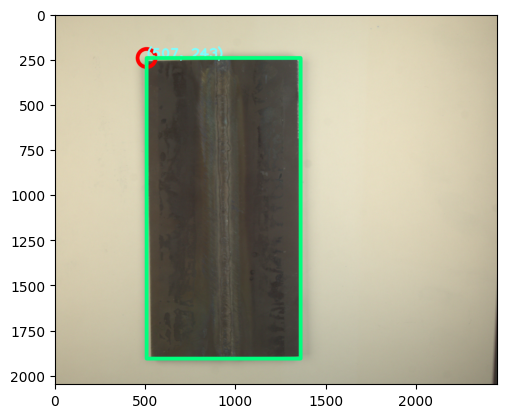

In [12]:
coordinate, masks = obj._getCoordinate_()

In [ ]:
coordinate

[834.0, 892.0, 1613.0, 906.0]

In [ ]:
masks

[{'segmentation': array([[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]]),
  'area': 1422651,
  'bbox': [834.0, 892.0, 1613.0, 906.0],
  'predicted_iou': 1.015023946762085,
  'point_coords': [[1568.25, 1696.0]],
  'stability_score': 0.9918719530105591,
  'crop_box': [0, 0, 2448, 2048]},
 {'segmentation': array([[ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         ...,
         [ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True]]),
  'area': 5006105,
  'bbox'

In [ ]:
# import cv2
# # img_cvt = cv2.imread('D:\Quan\\roboDK\Vision-Machine-collab-Nhan\VIKO_UltraRobot\Record_2024-04-19\\20240419-124548418601-acA2440-35uc_22481496.png')
# img_cvt = img.copy()

In [ ]:
# import numpy as np
# img_arr = np.asarray(img)

In [ ]:
# img_arr.shape

In [ ]:

# for mask in masks:
#     x, y, w, h = mask['bbox']
#     if (x == 441):
#         print(mask['bbox'])
#         cv2.rectangle(img_arr, (x, y), (x+w, y + h),   (0, 255, 0), thickness= 10)
#     # cv2.imshow('Show', img_cvt)
#     # cv2.waitKey(0)
#     # cv2.destroyAllWindows()
    

In [ ]:
# import matplotlib.pyplot as plt
# plt.imshow(img_arr)

In [ ]:
# plt.savefig('Record_2024-04-19/Masks1.png')

In [65]:
obj._end_()

In [1]:
import cv2
import tqdm
# read the image
image = cv2.imread('Record_2024-04-30/t1.png')
print(image.shape)
# convert the image to grayscale format
img_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# apply binary thresholding
ret, thresh = cv2.threshold(img_gray, 150, 255, cv2.THRESH_BINARY)
# visualize the binary image
cv2.imshow('Binary image', thresh)
cv2.waitKey(0)
cv2.imwrite('image_thres1.jpg', thresh)
cv2.destroyAllWindows()

# detect the contours on the binary image using cv2.CHAIN_APPROX_NONE
contours, hierarchy = cv2.findContours(image=thresh, mode=cv2.RETR_TREE, 
                                       method=cv2.CHAIN_APPROX_NONE)
for contour in tqdm.tqdm(contours):
    # draw contours on the original image
    image_copy = image.copy()
    area = cv2.contourArea(contour)
    # print(area)
    if area >1000:

        print(area)
        cv2.drawContours(image=image_copy, contours=contour, contourIdx=-1, 
                        color=(0, 255, 0), thickness=2, lineType=cv2.LINE_AA)
        M = cv2.moments(contour)
        if M['m00'] != 0:
            cx = float(M['m10'] / M['m00'])
            cy = float(M['m01'] / M['m00'])
            print(f"Coordinates of the center: ({cx}, {cy})")
        else:
            print("Could not find the center coordinates.")
        # see the results
        
        cv2.imshow('None approximation', image_copy)
        cv2.resizeWindow('None approximation', 500, 500)
        cv2.waitKey(0)
        cv2.imwrite('contours_none_image2_test.jpg', image_copy)
        cv2.destroyAllWindows()

(2048, 2448, 3)


 34%|███▍      | 491/1432 [00:02<00:04, 199.16it/s]

4977235.5
Coordinates of the center: (1216.3626630686854, 1017.4016877441303)


 99%|█████████▊| 1413/1432 [00:09<00:00, 185.17it/s]

2678.5
Coordinates of the center: (1566.568726277145, 820.6634310248273)
7036.5
Coordinates of the center: (1701.722210379213, 824.9528411378762)


100%|██████████| 1432/1432 [00:13<00:00, 102.95it/s]


In [2]:
def get_point(img):
    x, y = 0., 0.
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # apply binary thresholding
    ret, thresh = cv2.threshold(img_gray, 150, 255, cv2.THRESH_BINARY)

    # detect the contours on the binary image using cv2.CHAIN_APPROX_NONE
    contours, hierarchy = cv2.findContours(image=thresh, mode=cv2.RETR_TREE, 
                                        method=cv2.CHAIN_APPROX_NONE)
    for contour in contours:
        # draw contours on the original image
        image_copy = img.copy()
        area = cv2.contourArea(contour)
        # print(area)
        if 6000 < area < 10000:
            cv2.drawContours(image=image_copy, contours=contour, contourIdx=-1, 
                            color=(0, 255, 0), thickness=2, lineType=cv2.LINE_AA)
            M = cv2.moments(contour)
            if M['m00'] != 0:
                cx = float(M['m10'] / M['m00'])
                cy = float(M['m01'] / M['m00'])
                x, y, = cx, cy
                print(f"Coordinates of the center: ({cx}, {cy})")
            else:
                print("Could not find the center coordinates.")
        
    return x, y

In [3]:
x, y = get_point(image)
print(x)
print(y)

Coordinates of the center: (1701.722210379213, 824.9528411378762)
1701.722210379213
824.9528411378762
